In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from neuralprophet import NeuralProphet

In [2]:
df = pd.read_csv("../src/util/aws/vertica/vertica_data_20230530.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 939272 entries, 0 to 939271
Data columns (total 27 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   holdout            939272 non-null  int64  
 1   conversion         939272 non-null  int64  
 2   AMP_CLICK_DAY      939272 non-null  object 
 3   AMP_CLICK_HOUR     939272 non-null  int64  
 4   ACCOUNT_ID         939272 non-null  int64  
 5   CAMPAIGN_ID        939272 non-null  int64  
 6   ADGROUP_ID         939272 non-null  int64  
 7   KEYWORD_ID         939272 non-null  int64  
 8   CREATIVE_ID        939272 non-null  int64  
 9   ADCOPY_ID          939272 non-null  int64  
 10  PUBLISHER_ID       939272 non-null  int64  
 11  PUB_ATS_ID         939272 non-null  int64  
 12  PLACEMENT_ID       939272 non-null  int64  
 13  DEVICE_GROUP_ID    939272 non-null  int64  
 14  DEVICE_TYPE_ID     939272 non-null  int64  
 15  PUB_SUB_1          939272 non-null  object 
 16  PU

In [4]:
df['ds'] = pd.to_datetime(df['AMP_CLICK_DAY'], format = '%Y-%m-%d').dt.date

### ACCOUNT Level Prediction

In [5]:
combs = [
'ACCOUNT_ID'
]

In [6]:
df_agg = df[df['conversion']==1].groupby([*combs, 'ds']).agg({'order_value': 'sum', 'VALID_CLICKS': 'sum'}).reset_index()
df_agg['aov'] = df_agg['order_value'] / df_agg['VALID_CLICKS']
df_agg.sort_values([*combs, 'ds'])

,ACCOUNT_ID,ds,order_value,VALID_CLICKS,aov
0,74521,2022-12-01,93958.04,734,128.008229
1,74521,2022-12-02,136559.53,1006,135.745060
2,74521,2022-12-03,147489.96,1034,142.640193
3,74521,2022-12-04,116276.91,859,135.363108
4,74521,2022-12-05,152186.43,1077,141.305877
...,...,...,...,...,...
175,74521,2023-05-25,39887.06,310,128.667935
176,74521,2023-05-26,42476.15,323,131.505108
177,74521,2023-05-27,46539.69,329,141.458024
178,74521,2023-05-28,27084.11,220,123.109591


In [7]:
df_agg.rename(columns = {'aov':'y'}, inplace = True)
df_agg.head()

,ACCOUNT_ID,ds,order_value,VALID_CLICKS,y
0,74521,2022-12-01,93958.04,734,128.008229
1,74521,2022-12-02,136559.53,1006,135.745060
2,74521,2022-12-03,147489.96,1034,142.640193
3,74521,2022-12-04,116276.91,859,135.363108
4,74521,2022-12-05,152186.43,1077,141.305877


In [8]:
ts_data = pd.DataFrame({
    'ds': df_agg.ds,
    'y': np.log(df_agg.y)})

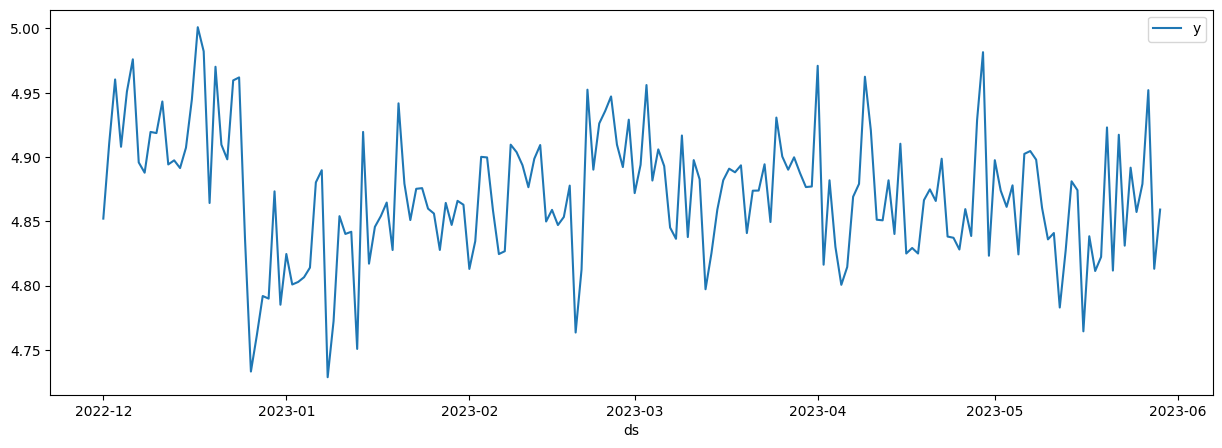

In [9]:
plt = ts_data.plot(x="ds", y="y", figsize=(15, 5))

### Setting up the model

Autoregression is a time series model that uses observations from previous time steps as input to a regression equation to predict the value at the next time step.

In [17]:
# Import the NeuralProphet class
from neuralprophet import NeuralProphet, set_log_level

# Disable logging messages unless there is an error
set_log_level("ERROR")

# Create a NeuralProphet model with default parameters
m = NeuralProphet(
    # Disable change trendpoints
    n_changepoints=0,
    # Disable seasonality components
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
)

# Use static plotly in notebooks
m.set_plotting_backend("matplotlib")

# Fit the model on the dataset (this might take a bit)
df_train, df_val = m.split_df(ts_data, freq='D', valid_p = 0.2)
metrics = m.fit(df_train, freq='D', validation_df=df_val)

Finding best initial lr:   0%|          | 0/209 [00:00<?, ?it/s]

Training: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

...

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

### Forecast the future

Predicting: 9it [00:00, ?it/s]

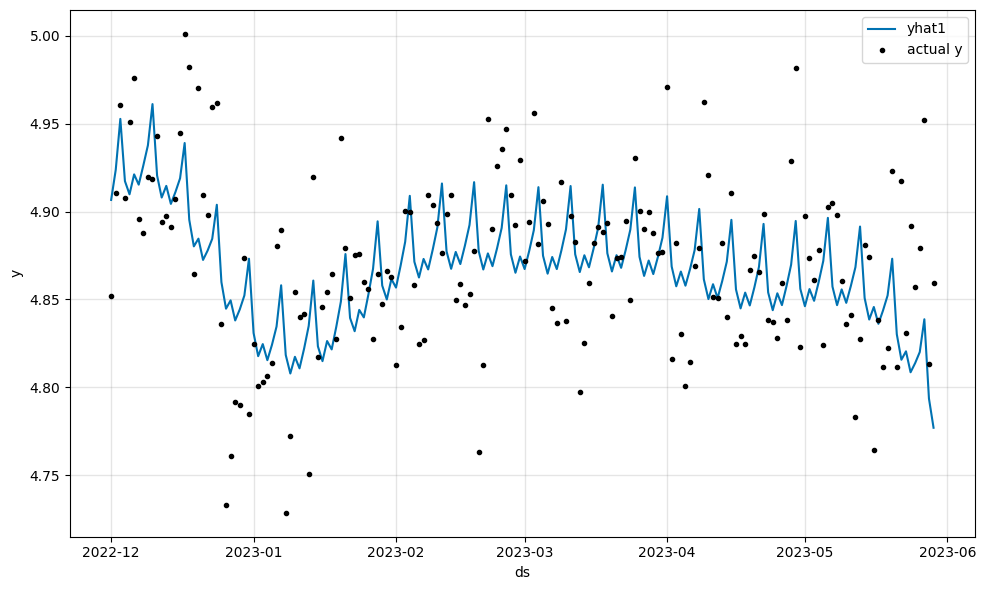

In [18]:
df_future = m.make_future_dataframe(ts_data, n_historic_predictions=True, periods=0)

# Predict the future
forecast = m.predict(df_future)

# Visualize the forecast
m.plot(forecast)

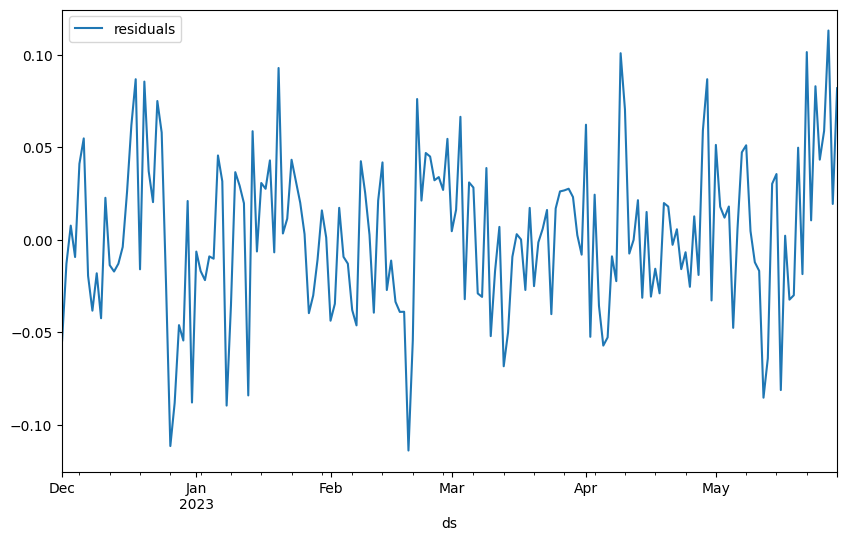

In [19]:
df_residuals = pd.DataFrame({"ds": forecast["ds"], "residuals": forecast["y"] - forecast["yhat1"]})
fig = df_residuals.plot(x="ds", y="residuals", figsize=(10, 6))

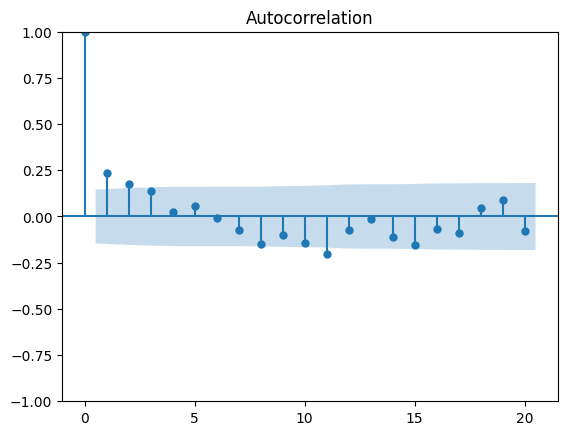

In [20]:
from statsmodels.graphics.tsaplots import plot_acf

plt = plot_acf(df_residuals["residuals"], lags=20)

Interpret the Autocorrelation Chart: Examine the ACF plot to identify any significant autocorrelation patterns. Some key points to consider are:

Significance: Look for autocorrelation coefficients that are statistically significant. Typically, a dashed line is drawn on the plot to represent the 95% confidence interval. Coefficients outside this interval indicate significant correlations.

Positive/Negative Correlation: Determine whether the autocorrelation coefficients are positive or negative. Positive autocorrelation suggests that high values are followed by high values and vice versa. Negative autocorrelation indicates an inverse relationship.

Lag Duration: Consider the duration of the lag at which significant autocorrelation occurs. This can help identify the periodicity or seasonality in the data.

Decay: Observe how the autocorrelation coefficients decay over time. A slow decay suggests a long memory in the time series, while a rapid decay indicates a short memory.

If you observe alternate patterns of high and low values in the autocorrelation function (ACF) plot, with a sharp drop from 0 to 1, it suggests the presence of a seasonal or periodic pattern in the time series data. This pattern is known as seasonal autocorrelation.

The alternate pattern you see in the ACF plot indicates that there is a significant correlation between observations that are a certain number of lags apart, with a periodicity equal to the lag at which the correlation is highest.

Finding best initial lr:   0%|          | 0/211 [00:00<?, ?it/s]

Training: 0it [00:00, ?it/s]

Predicting: 11it [00:00, ?it/s]

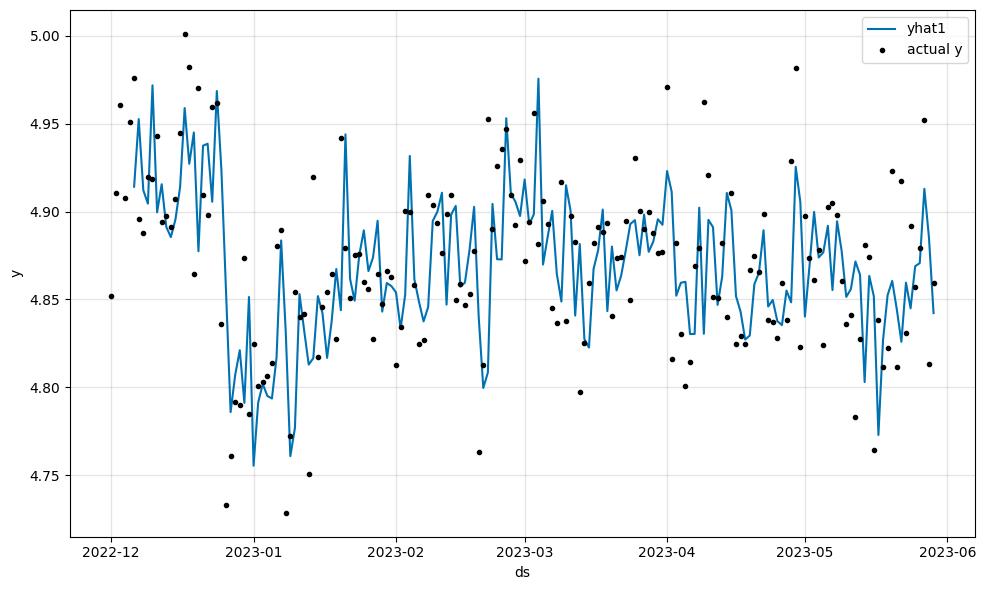

In [27]:
# Model and prediction
m = NeuralProphet(
    # Disable trend changepoints
    # Disable seasonality components
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    # Add the autogression
    n_lags=5,
)
m.set_plotting_backend("matplotlib")  # Use matplotlib due to #1235
metrics = m.fit(ts_data)
forecast = m.predict(ts_data)
m.plot(forecast)

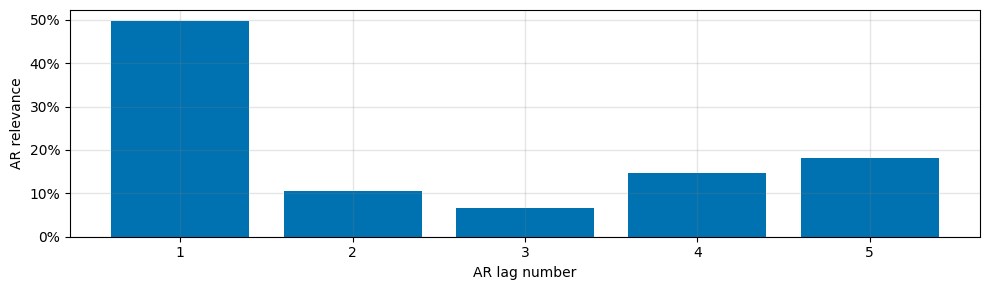

In [28]:
m.plot_parameters(components=["autoregression"])

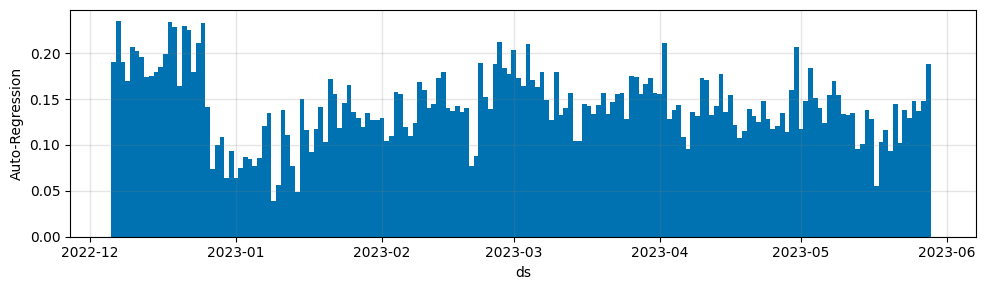

In [29]:
m.plot_components(forecast, components=["autoregression"])